PART A: DATASET UNDERSTANDING
Domain: Transportation / Disaster Survival
Records: 891, Attributes: 12
Target Variable: Survived (0 = Died, 1 = Survived)
Purpose: To analyse passenger data and understand factors that affected survival in the Titanic disaster
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2   

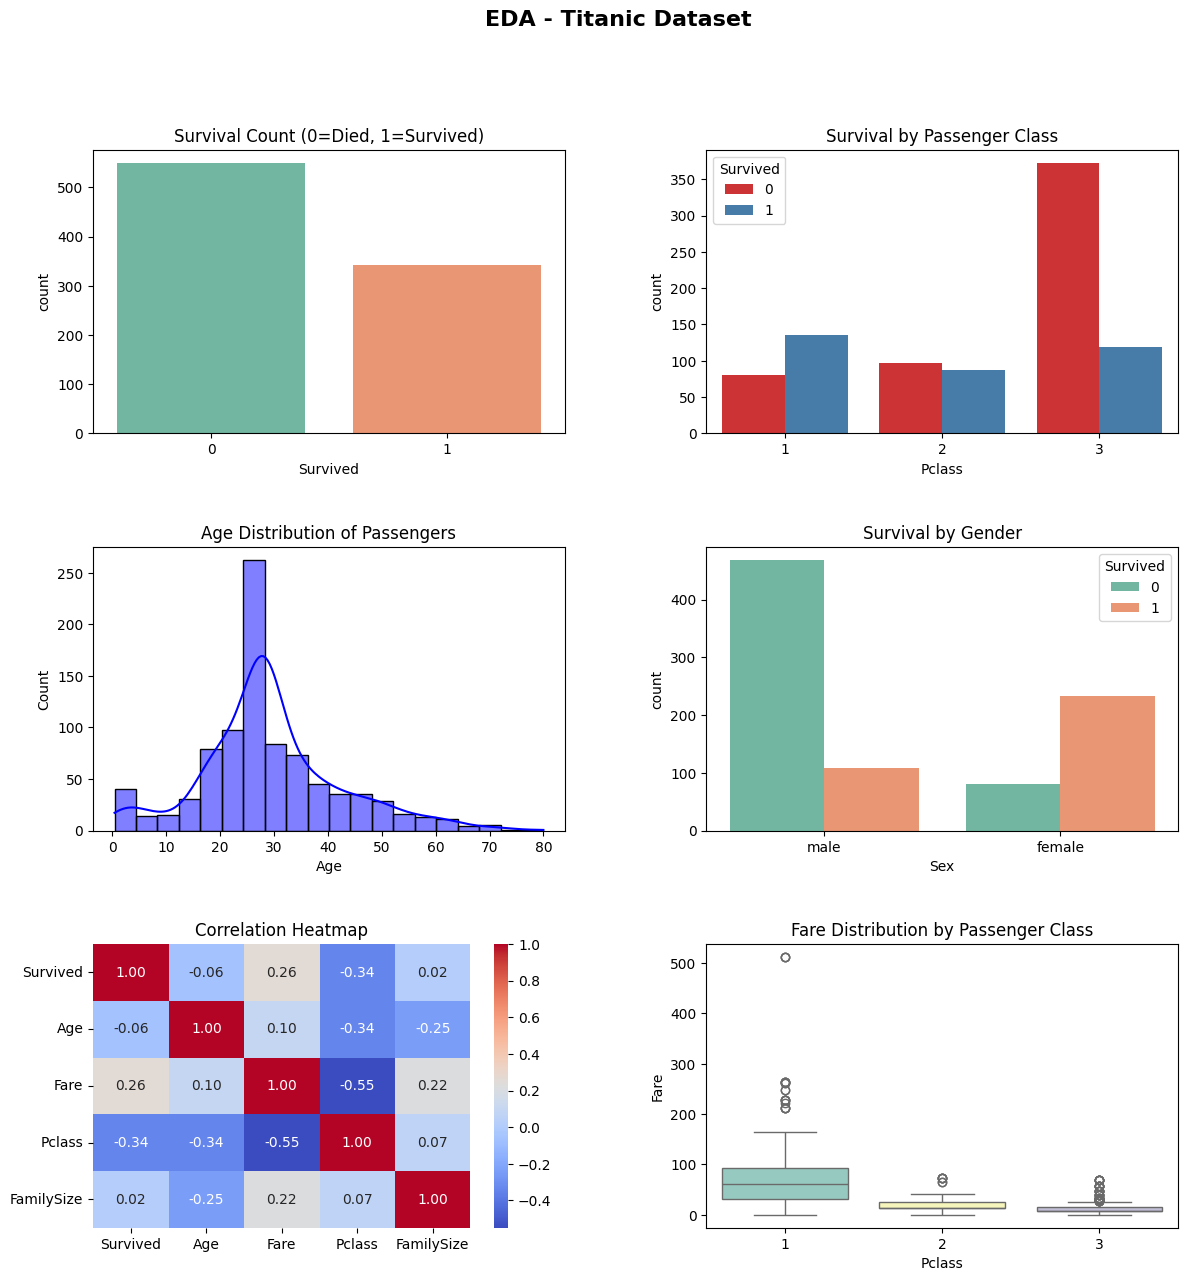

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("PART A: DATASET UNDERSTANDING")

print("Domain: Transportation / Disaster Survival")
print(f"Records: {df.shape[0]}, Attributes: {df.shape[1]}")
print("Target Variable: Survived (0 = Died, 1 = Survived)")
print("Purpose: To analyse passenger data and understand factors that affected survival in the Titanic disaster")
print(df.dtypes)
print(df.head())

print("PART B: DATA QUALITY ASSESSMENT")

print("Missing Values:")
print(df.isnull().sum())
print("Missing Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))
print("Duplicates:", df.duplicated().sum())
print("Invalid Age values (below 0):", len(df[df["Age"] < 0]))
print("Invalid Fare values (below 0):", len(df[df["Fare"] < 0]))

df.drop(columns=["Cabin"], inplace=True)
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

print("After Cleaning - Missing Values:")
print(df.isnull().sum())
print("Handling Methods:")
print("  Age     : Filled missing values with median age")
print("  Cabin   : Dropped (77% missing, not useful)")
print("  Embarked: Filled with most common port")

print("PART C: FEATURE ANALYSIS")

print("Feature Categories:")
print("  Survived  - Binary       (0 = Died, 1 = Survived) TARGET")
print("  Pclass    - Ordinal      (1 = First, 2 = Second, 3 = Third class)")
print("  Sex       - Categorical  (male / female)")
print("  Age       - Continuous   (age in years)")
print("  SibSp     - Discrete     (number of siblings/spouses aboard)")
print("  Parch     - Discrete     (number of parents/children aboard)")
print("  Fare      - Continuous   (ticket price paid)")
print("  Embarked  - Categorical  (C = Cherbourg, Q = Queenstown, S = Southampton)")
print("  Name, Ticket, PassengerId - Not useful for ML (redundant/ID columns)")

print("Correlation Matrix:")
print(df[["Survived","Pclass","Age","Fare","SibSp","Parch"]].corr().round(2))

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]    = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "male").astype(int)

print("New Features Created:")
print("  FamilySize  = SibSp + Parch + 1  (total family members on board)")
print("  IsAlone     = 1 if FamilySize==1 (travelling alone or not)")
print("  Sex_encoded = 1 for male, 0 for female (for ML use)")

print("PART D: INSIGHT GENERATION")

print("Summary Statistics:")
print(df[["Age","Fare","Pclass","SibSp","Parch"]].describe().round(2))

survival_rate = round(df["Survived"].mean() * 100, 2)
avg_age       = round(df["Age"].mean(), 2)
avg_fare      = round(df["Fare"].mean(), 2)
best_class    = df.groupby("Pclass")["Survived"].mean().idxmax()

print(f"Overall Survival Rate : {survival_rate}%")
print(f"Average Age           : {avg_age} years")
print(f"Average Fare          : ${avg_fare}")
print(f"Best Surviving Class  : Class {best_class}")

print("Survival by Gender:")
print(df.groupby("Sex")["Survived"].mean().round(2))
print("Survival by Class:")
print(df.groupby("Pclass")["Survived"].mean().round(2))
print("Survival by Alone vs Family:")
print(df.groupby("IsAlone")["Survived"].mean().round(2))

print("Key Findings:")
print("  1. Only 38% of passengers survived the Titanic disaster")
print("  2. Women had a much higher survival rate than men")
print("  3. 1st class passengers survived more than 2nd and 3rd class")
print("  4. Passengers travelling with family survived more than those alone")
print("  5. Higher fare paid = better chance of survival")
print("  6. Most passengers boarded from Southampton (S)")

print("Business / Domain Implications:")
print("  - Gender and class were the biggest factors in who survived")
print("  - Emergency evacuation protocols clearly favoured women and upper class")
print("  - Family presence improved survival, possibly due to group cooperation")
print("  - Fare/class is a strong predictor — useful for ML models")

print("Recommended ML Tasks:")
print("  1. Classification : Predict survival (Logistic Regression, Random Forest)")
print("  2. Feature Importance : Find top features using Decision Tree")
print("  3. Clustering : Group passengers by similar characteristics")
print("  4. Cross-validation : Evaluate model accuracy on unseen data")

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("EDA - Titanic Dataset", fontsize=16, fontweight="bold")
plt.subplots_adjust(hspace=0.4, wspace=0.3)

sns.countplot(x="Survived", data=df, ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Survival Count (0=Died, 1=Survived)")
axes[0,0].set_xlabel("Survived")

sns.countplot(x="Pclass", hue="Survived", data=df, ax=axes[0,1], palette="Set1")
axes[0,1].set_title("Survival by Passenger Class")

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[1,0], color="blue")
axes[1,0].set_title("Age Distribution of Passengers")

sns.countplot(x="Sex", hue="Survived", data=df, ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Survival by Gender")

sns.heatmap(df[["Survived","Age","Fare","Pclass","FamilySize"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2,0])
axes[2,0].set_title("Correlation Heatmap")

sns.boxplot(x="Pclass", y="Fare", data=df, ax=axes[2,1], palette="Set3")
axes[2,1].set_title("Fare Distribution by Passenger Class")

plt.savefig("Mathew_530_Lab1_plots.png", bbox_inches="tight")
plt.show()